In [1]:
# ── Cell 5: load results (handles both single-file and sharded output) ──────
import glob
import pandas as pd

OUTPUT_CSV = "./results/results_dp_sbm_comparison_with_epochs.csv"   # match OUTPUT_CSV in the driver script

shard_files = sorted(glob.glob(f"{OUTPUT_CSV}.shard*"))
if shard_files:
    df = pd.concat([pd.read_csv(f) for f in shard_files], ignore_index=True)
    print(f"Loaded {len(shard_files)} shard files, {len(df)} rows total.")
else:
    df = pd.read_csv(OUTPUT_CSV)
    print(f"Loaded {OUTPUT_CSV}, {len(df)} rows.")

# ── Drop the sigma=0.1 grid point ──────────────────────────────────────────
# At sigma=0.1 the accountant returns epsilon ~ 1605 (1.6e+03). np.exp(epsilon)
# in edge_flip/p_flip overflows float64 there (exp overflows above ~709.8), so
# that point's beta/NMI values are unreliable. It is also no privacy at all
# (epsilon in the thousands), so it carries no information -- exclude it from
# every plot below.
_n_before = len(df)
df = df[df["sigma"] != 0.1].reset_index(drop=True)
print(f"Excluded sigma=0.1 (epsilon~1.6e+03, overflow): dropped {_n_before - len(df)} rows, {len(df)} remain.")

df.head()

Loaded ./results/results_dp_sbm_comparison_with_epochs.csv, 720 rows.
Excluded sigma=0.1 (epsilon~1.6e+03, overflow): dropped 120 rows, 600 remain.


,N,sigma,epsilon,rep,method,epsilon_gamma,epsilon_beta,epsilon_rho,epochs,epochs_gamma,epochs_beta,delta,beta_true_00,beta_true_01,beta_true_11,beta_est_00,beta_est_01,beta_est_11,nmi
0,100,0.5,75.261074,0,edge_flip_vem,NaN,NaN,NaN,279.0,NaN,NaN,0.00001,0.2,0.02,0.2,0.203265,0.017200,0.217959,1.000000
1,100,0.5,75.261074,0,sbm_dpsgd_all_noised,70.772185,12.423129,1.033895,11.0,6.0,5.0,0.00001,0.2,0.02,0.2,0.152330,0.125008,0.188686,0.011645
2,100,0.5,75.261074,1,edge_flip_vem,NaN,NaN,NaN,222.0,NaN,NaN,0.00001,0.2,0.02,0.2,0.200816,0.026400,0.194286,1.000000
3,100,0.5,75.261074,1,sbm_dpsgd_all_noised,70.772185,12.423129,1.033895,11.0,6.0,5.0,0.00001,0.2,0.02,0.2,0.147660,0.120537,0.195843,0.053714
4,100,0.5,75.261074,2,edge_flip_vem,NaN,NaN,NaN,189.0,NaN,NaN,0.00001,0.2,0.02,0.2,0.213061,0.016400,0.202449,1.000000


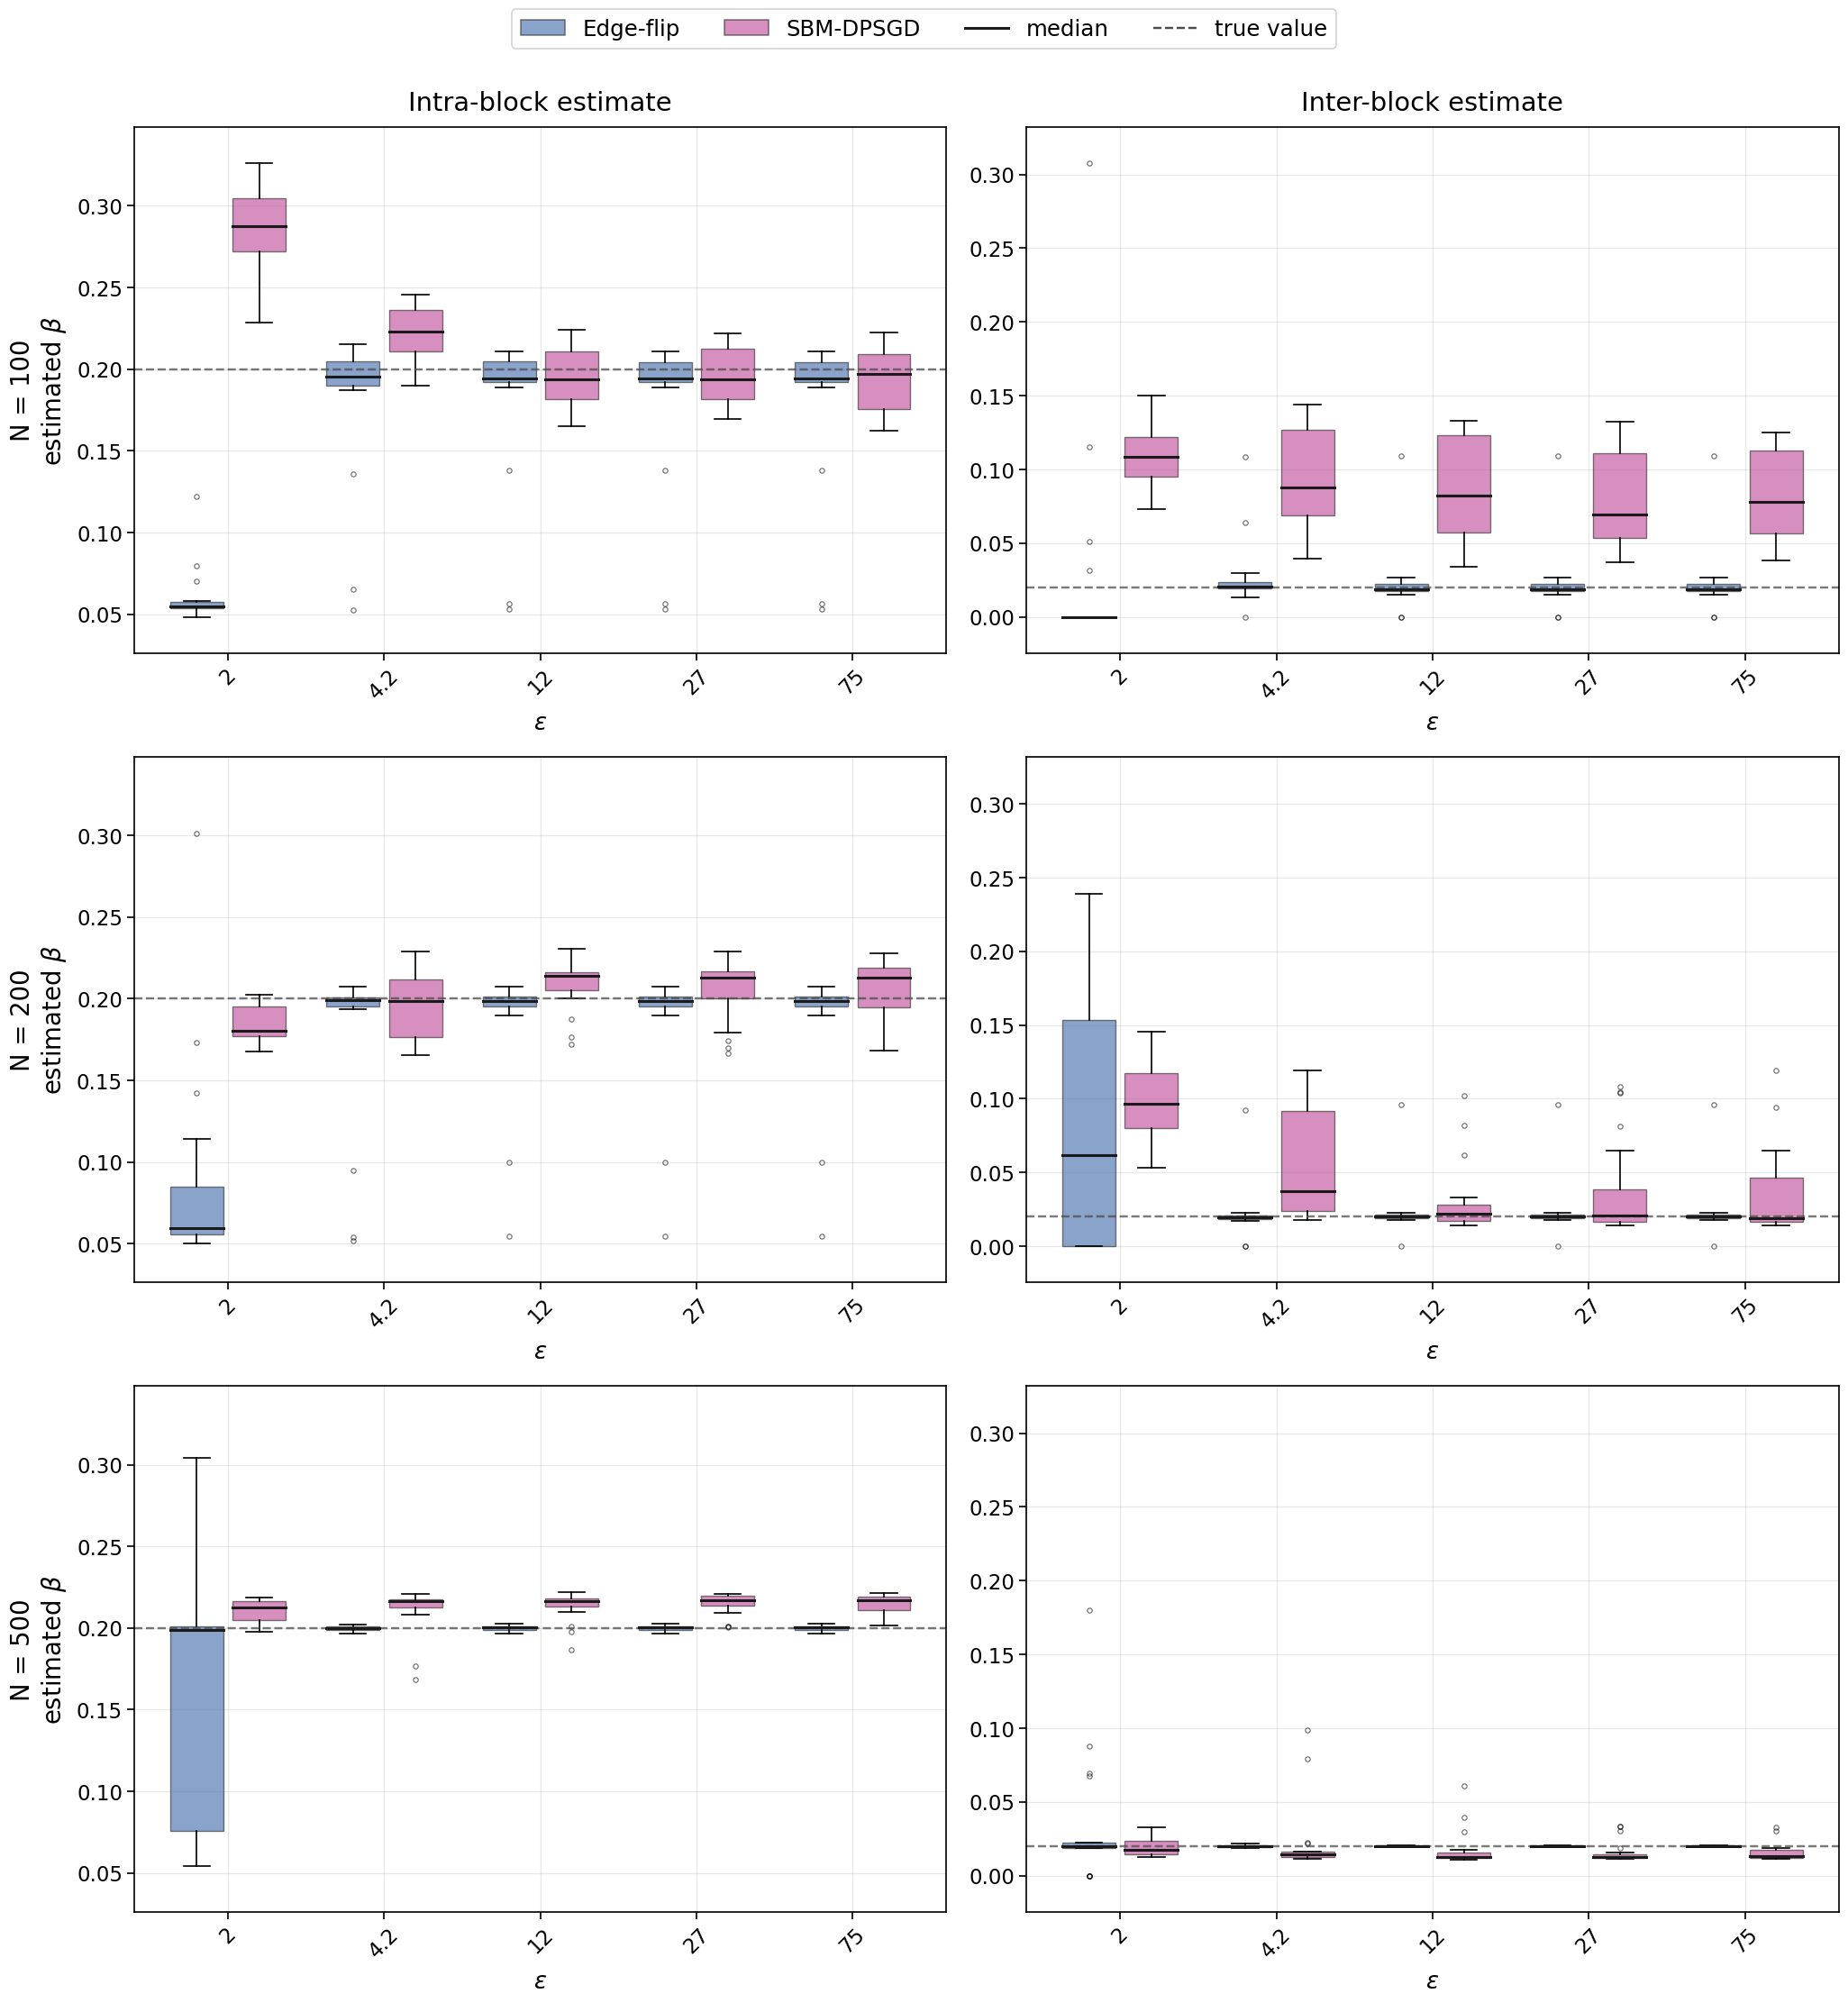

In [2]:
# ── Cell 6: Boxplots of estimated beta vs epsilon ───────────────────────────
# Layout: one ROW per N, two COLUMNS (intra-block, inter-block) -- large panels
# sized for a thesis figure, so each one survives being scaled down in LaTeX.
#
# Shared scales: both panels in the LEFT column share one y-limit and both in
# the RIGHT column share another, so N-to-N comparisons down a column are
# honest. Intra and inter are NOT put on a common scale -- the true values
# differ by 10x (0.2 vs 0.02) and a shared axis would flatten the inter column.
#
# Colours/labels/median style come from plot_style.py so every figure in the
# thesis uses the same colour for the same method.
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from plot_style import (apply_style, figsize, grouped_boxplot, method_color,
                        method_label, order_methods, reference_line,
                        BOX_ALPHA, MEDIAN_COLOR, REFERENCE_COLOR)

apply_style()

Ns = sorted(df["N"].unique())
methods = order_methods(df["method"].unique())

# Per-panel inches before FIG_SCALE -- the single knob for retuning size.
PANEL_W, PANEL_H = 7.0, 5.0

fig, axes = plt.subplots(
    len(Ns), 2,
    figsize=figsize(PANEL_W * 2, PANEL_H * len(Ns)),
    squeeze=False,
)

# ── precompute per-column y-limits (shared down each column) ────────────────
df_intra_est = df[["beta_est_00", "beta_est_11"]].mean(axis=1)
intra_ymin, intra_ymax = df_intra_est.min(), df_intra_est.max()
inter_ymin, inter_ymax = df["beta_est_01"].min(), df["beta_est_01"].max()

intra_true_vals = df["beta_true_00"].unique()
inter_true_vals = df["beta_true_01"].unique()
intra_ymin = min(intra_ymin, intra_true_vals.min())
intra_ymax = max(intra_ymax, intra_true_vals.max())
inter_ymin = min(inter_ymin, inter_true_vals.min())
inter_ymax = max(inter_ymax, inter_true_vals.max())

def pad(lo, hi, frac=0.08):
    span = hi - lo
    if span == 0:
        span = abs(hi) if hi != 0 else 1.0
    return lo - frac * span, hi + frac * span

COLUMNS = [
    ("intra_est",   "beta_true_00", "Intra-block estimate", pad(intra_ymin, intra_ymax)),
    ("beta_est_01", "beta_true_01", "Inter-block estimate", pad(inter_ymin, inter_ymax)),
]

for row, N in enumerate(Ns):
    sub = df[df["N"] == N].copy()
    sub["intra_est"] = sub[["beta_est_00", "beta_est_11"]].mean(axis=1)

    for col, (est_col, true_col, col_title, ylim) in enumerate(COLUMNS):
        ax = axes[row, col]
        grouped_boxplot(ax, sub, est_col, methods=methods)
        reference_line(ax, sub[true_col].iloc[0])
        ax.set_ylim(ylim)
        ax.set_xlabel(r"$\epsilon$")
        if row == 0:
            ax.set_title(col_title, fontsize=19, pad=12)

    # N labels the row, stated once on the left instead of in every panel title.
    axes[row, 0].set_ylabel(f"N = {N}\n" r"estimated $\beta$", fontsize=18)

# One figure-level legend: at this panel size a per-panel legend would either
# cover data or be repeated six times.
handles = [Patch(facecolor=method_color(m), alpha=BOX_ALPHA, edgecolor="#333333",
                 label=method_label(m)) for m in methods]
handles += [
    Line2D([0], [0], color=MEDIAN_COLOR, linewidth=2.0, label="median"),
    Line2D([0], [0], color=REFERENCE_COLOR, linestyle="--", linewidth=1.6,
           label="true value"),
]
fig.legend(handles=handles, loc="upper center", ncol=len(handles),
           fontsize=16, frameon=True, bbox_to_anchor=(0.5, 1.005))

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

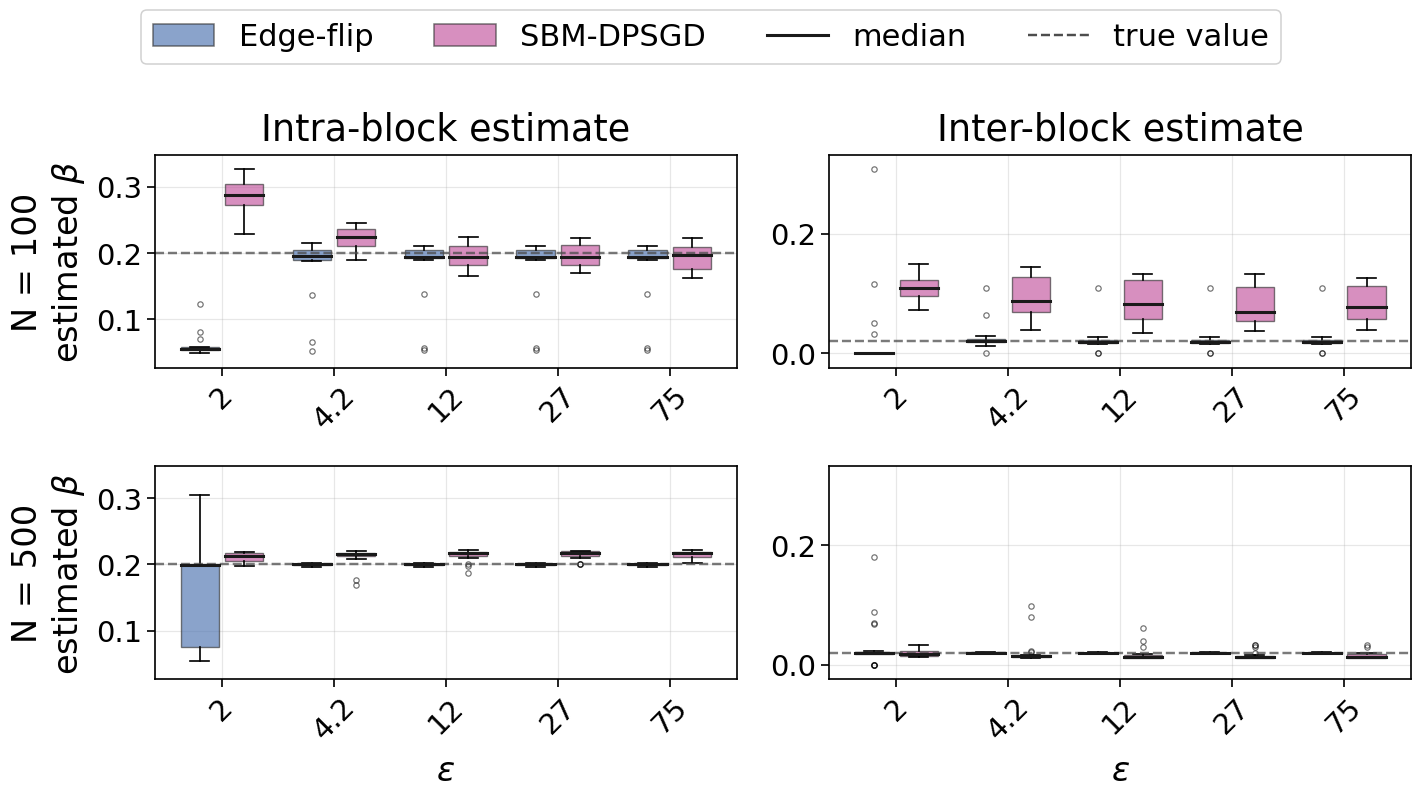

In [3]:
# ── Cell 6b: SLIDE version of the beta figure (N = 200 dropped) ─────────────
# Same data, same layout logic and same shared-scale rules as Cell 6, but
# sized for a talk rather than a thesis page:
#   * N = 200 is dropped -- N = 100 and N = 500 already bracket the trend, and
#     three rows do not fit a 16:9 frame without shrinking each panel to
#     illegibility.
#   * The canvas is exactly one 16:9 slide (13.33 x 7.5 in), so font sizes in
#     points are LITERAL slide points -- no guessing at how LaTeX/PowerPoint
#     will rescale it.
#   * Type is set larger inside a rc_context, so this cell does not leak its
#     slide styling into the thesis figures above/below.
# y-limits are recomputed from the N in {100, 500} subset only, so dropping
# N = 200 does not leave dead vertical space reserved for a row that is no
# longer drawn.
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from plot_style import (apply_style, grouped_boxplot, method_color,
                        method_label, order_methods, reference_line,
                        BOX_ALPHA, MEDIAN_COLOR, REFERENCE_COLOR)

apply_style()

SLIDE_NS = [100, 500]          # the N values shown on slides
SLIDE_W, SLIDE_H = 13.33, 7.5  # one 16:9 slide, at 1:1
SLIDE_RC = {
    "font.size": 20,
    "axes.labelsize": 22,
    "xtick.labelsize": 19,
    "ytick.labelsize": 19,
    "legend.fontsize": 20,
}

dfs = df[df["N"].isin(SLIDE_NS)].copy()
Ns_slide = [n for n in SLIDE_NS if n in set(dfs["N"])]
methods = order_methods(dfs["method"].unique())

# ── per-column y-limits, shared down each column (slide subset only) ────────
_intra_est = dfs[["beta_est_00", "beta_est_11"]].mean(axis=1)
intra_lo = min(_intra_est.min(), dfs["beta_true_00"].min())
intra_hi = max(_intra_est.max(), dfs["beta_true_00"].max())
inter_lo = min(dfs["beta_est_01"].min(), dfs["beta_true_01"].min())
inter_hi = max(dfs["beta_est_01"].max(), dfs["beta_true_01"].max())

def pad(lo, hi, frac=0.08):
    span = hi - lo
    if span == 0:
        span = abs(hi) if hi != 0 else 1.0
    return lo - frac * span, hi + frac * span

COLUMNS = [
    ("intra_est",   "beta_true_00", "Intra-block estimate", pad(intra_lo, intra_hi)),
    ("beta_est_01", "beta_true_01", "Inter-block estimate", pad(inter_lo, inter_hi)),
]

with plt.rc_context(SLIDE_RC):
    fig, axes = plt.subplots(len(Ns_slide), 2, figsize=(SLIDE_W, SLIDE_H),
                             squeeze=False)

    for row, N in enumerate(Ns_slide):
        sub = dfs[dfs["N"] == N].copy()
        sub["intra_est"] = sub[["beta_est_00", "beta_est_11"]].mean(axis=1)

        for col, (est_col, true_col, col_title, ylim) in enumerate(COLUMNS):
            ax = axes[row, col]
            grouped_boxplot(ax, sub, est_col, methods=methods)
            reference_line(ax, sub[true_col].iloc[0])
            ax.set_ylim(ylim)
            # Only the bottom row carries the x label: the two rows share the
            # same epsilon grid, and on a slide the repeat is just clutter.
            if row == len(Ns_slide) - 1:
                ax.set_xlabel(r"$\epsilon$")
            if row == 0:
                ax.set_title(col_title, fontsize=24, pad=10)

        axes[row, 0].set_ylabel(f"N = {N}\n" r"estimated $\beta$", fontsize=22)

    handles = [Patch(facecolor=method_color(m), alpha=BOX_ALPHA,
                     edgecolor="#333333", label=method_label(m))
               for m in methods]
    handles += [
        Line2D([0], [0], color=MEDIAN_COLOR, linewidth=2.0, label="median"),
        Line2D([0], [0], color=REFERENCE_COLOR, linestyle="--", linewidth=1.6,
               label="true value"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=len(handles),
               fontsize=20, frameon=True, bbox_to_anchor=(0.5, 1.0))

    fig.tight_layout(rect=[0, 0, 1, 0.90])
    fig.savefig("figures/slide_beta_unknown_labels.png", dpi=200)
    plt.show()

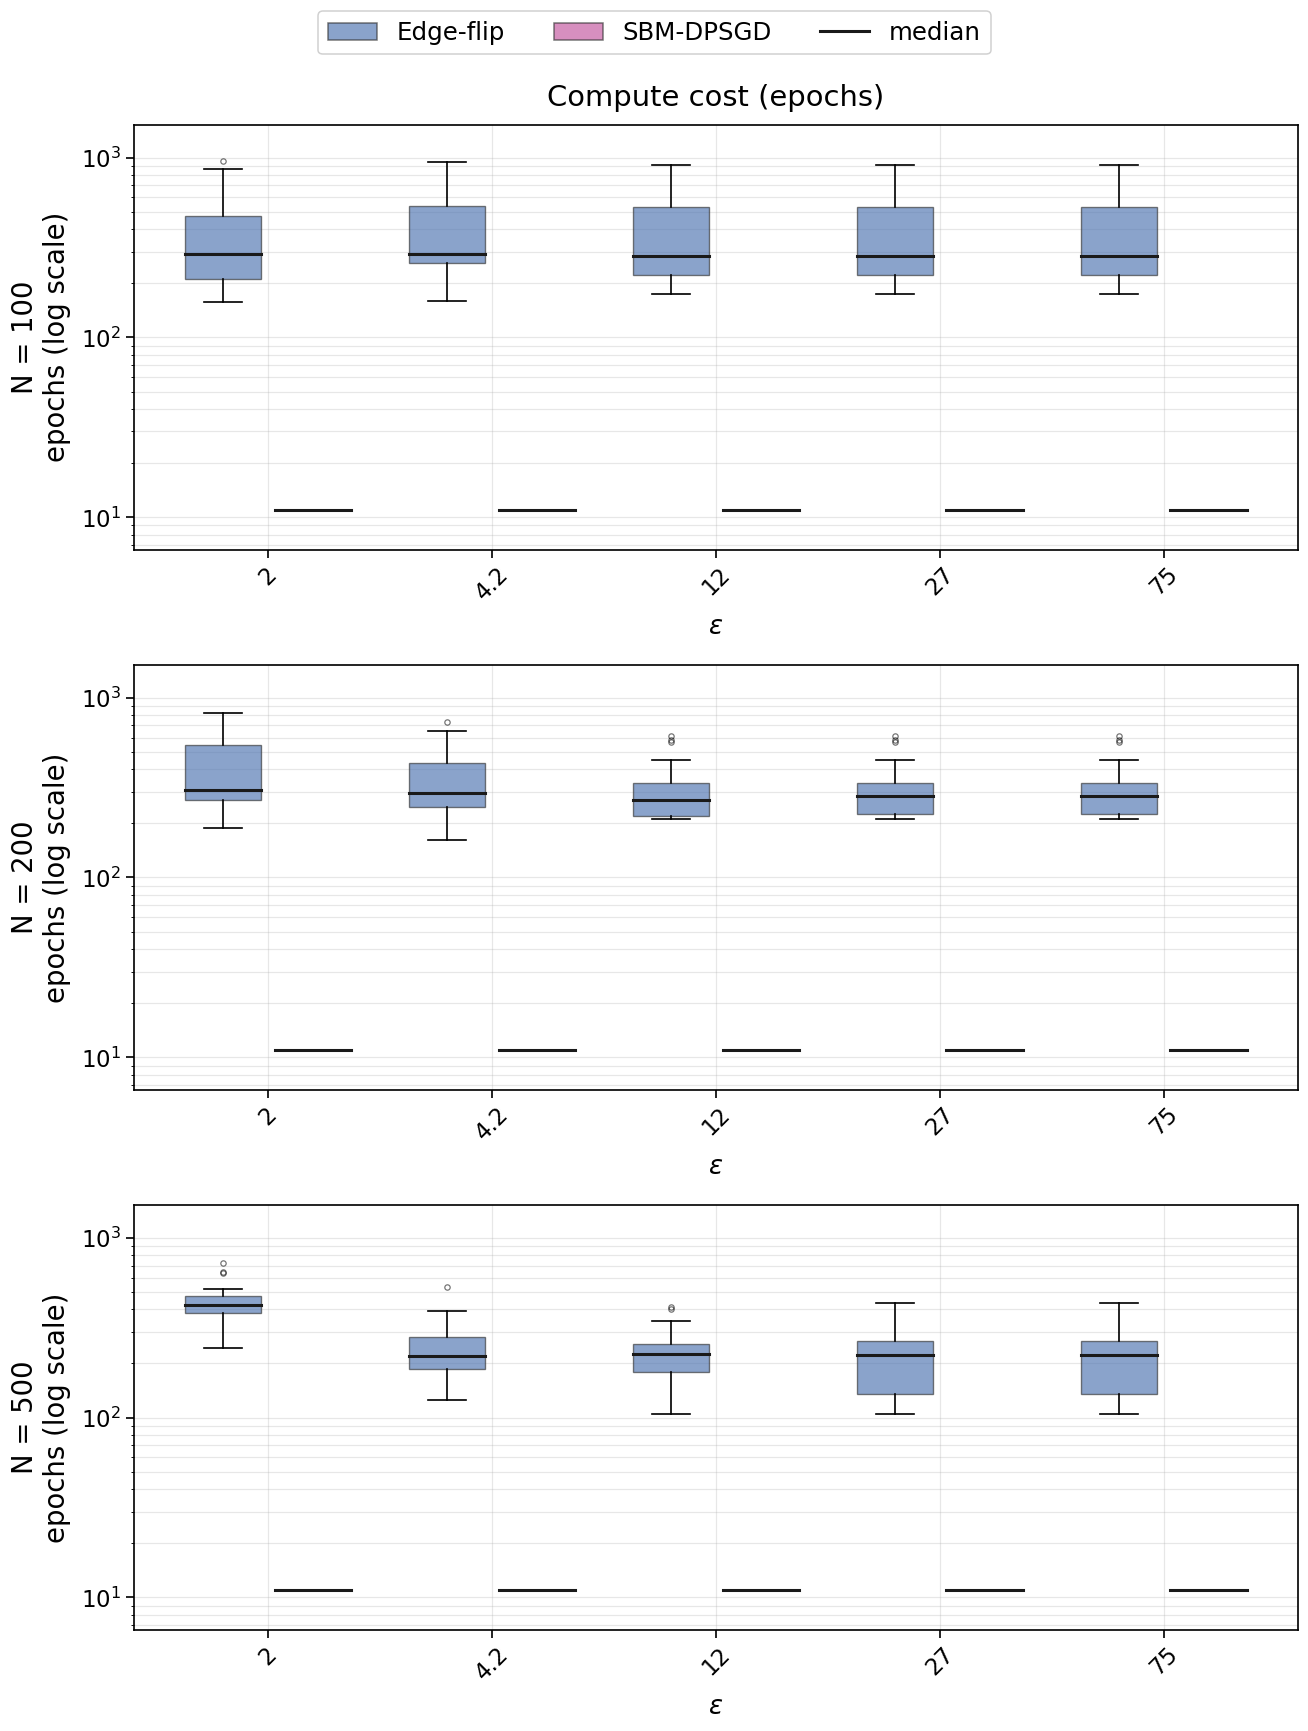

In [4]:
# ── Cell 7: Boxplots of # epochs (compute cost) vs epsilon ──────────────────
# Layout: one ROW per N, one large panel each -- same row-per-N structure as
# the beta figure, so the three figures read as a set.
# Log scale: the methods differ by ~1-2 orders of magnitude, so a linear axis
# squashes the cheaper one flat near zero. The y-limits are shared across rows
# so the N-to-N comparison down the column is honest.
# CAVEAT: an epoch is NOT wall-clock comparable across methods -- a VEM epoch
# is a dense O(N^2) matmul pass, an SBM-DPSGD epoch is a sampled
# per-example-autodiff pass.
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from plot_style import (apply_style, figsize, grouped_boxplot, method_color,
                        method_label, order_methods, BOX_ALPHA, MEDIAN_COLOR)

apply_style()

Ns = sorted(df["N"].unique())
methods = order_methods(df["method"].unique())

PANEL_W, PANEL_H = 9.0, 3.9

fig, axes = plt.subplots(
    len(Ns), 1,
    figsize=figsize(PANEL_W, PANEL_H * len(Ns)),
    squeeze=False,
)

ep = df["epochs"].dropna()
ylim = (ep.min() * 0.6, ep.max() * 1.6)     # shared across rows (log scale)

for row, N in enumerate(Ns):
    ax = axes[row, 0]
    grouped_boxplot(ax, df[df["N"] == N], "epochs", methods=methods)
    ax.set_yscale("log")
    ax.set_ylim(ylim)
    ax.set_xlabel(r"$\epsilon$")
    ax.set_ylabel(f"N = {N}\nepochs (log scale)", fontsize=18)
    ax.grid(alpha=0.3, which="both")
    if row == 0:
        ax.set_title("Compute cost (epochs)", fontsize=19, pad=12)

handles = [Patch(facecolor=method_color(m), alpha=BOX_ALPHA, edgecolor="#333333",
                 label=method_label(m)) for m in methods]
handles.append(Line2D([0], [0], color=MEDIAN_COLOR, linewidth=2.0, label="median"))
fig.legend(handles=handles, loc="upper center", ncol=len(handles),
           fontsize=16, frameon=True, bbox_to_anchor=(0.5, 1.005))

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

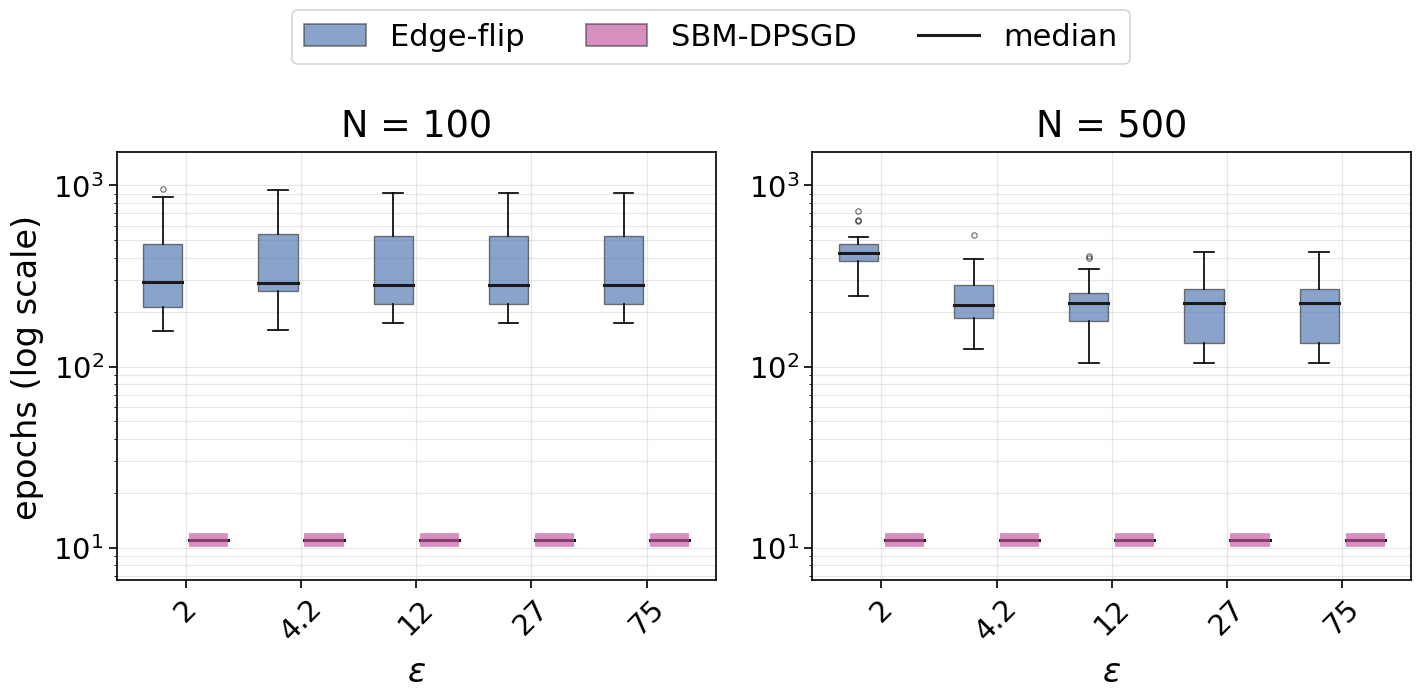

In [5]:
# ── Cell 7b: SLIDE version of the epochs figure (N = 200 dropped) ───────────
# Same data and same caveat as Cell 7 (an epoch is NOT wall-clock comparable
# across methods), re-laid-out for a talk:
#   * N = 200 dropped, so only N = 100 and N = 500 are shown.
#   * The two N go SIDE BY SIDE rather than stacked. With only two panels left,
#     a 16:9 frame is much wider than it is tall, so two columns give each
#     panel far more area than two short rows would.
#   * Canvas is one 16:9 slide minus room for the slide's own title bar, so
#     point sizes here are literal slide points.
#   * Constant-valued groups are re-coloured (see mark_flat_groups below).
# Shared log y-limits across both panels, as in Cell 7, so the N-to-N
# comparison stays honest.
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from plot_style import (apply_style, box_positions, grouped_boxplot,
                        method_color, method_label, order_methods, BOX_ALPHA,
                        MEDIAN_COLOR)

apply_style()

SLIDE_NS = [100, 500]
SLIDE_W, SLIDE_H = 13.33, 6.6   # 16:9 slide, minus space for a slide title
SLIDE_RC = {
    "font.size": 20,
    "axes.labelsize": 22,
    "xtick.labelsize": 19,
    "ytick.labelsize": 19,
    "legend.fontsize": 20,
}

dfs = df[df["N"].isin(SLIDE_NS)]
Ns_slide = [n for n in SLIDE_NS if n in set(dfs["N"])]
methods = order_methods(dfs["method"].unique())

ep = dfs["epochs"].dropna()
ylim = (ep.min() * 0.6, ep.max() * 1.6)     # shared across panels (log scale)


def mark_flat_groups(ax, data, value_col, methods, x_values, x_col="epsilon",
                     method_col="method"):
    """
    Draw a method-coloured bar under any box whose values are all identical.

    SBM-DPSGD spends the same number of epochs in every rep, so its box has
    zero height and matplotlib renders it as the median line alone -- in
    MEDIAN_COLOR, i.e. near-black. On the page that is merely subtle; on a
    slide it means the magenta legend key points at nothing the audience can
    find. This redraws those groups as a short bar in the method's own colour,
    with the black median still on top, so a flat group reads as "a box that
    happens to have no spread" rather than as a stray rule.

    Positions come from plot_style.box_positions, the same helper
    grouped_boxplot draws with, so the bars cannot drift off their boxes.
    """
    pos_map, width = box_positions(methods, x_values)
    for xv in x_values:
        for m in methods:
            vals = data.loc[(data[x_col] == xv) & (data[method_col] == m),
                            value_col].dropna()
            if len(vals) == 0 or vals.nunique() > 1:
                continue
            x = pos_map[(xv, m)]
            half = width * 0.85 / 2
            ax.plot([x - half, x + half], [vals.iloc[0]] * 2,
                    color=method_color(m), alpha=BOX_ALPHA, solid_capstyle="butt",
                    linewidth=9, zorder=2.4)


with plt.rc_context(SLIDE_RC):
    fig, axes = plt.subplots(1, len(Ns_slide), figsize=(SLIDE_W, SLIDE_H),
                             squeeze=False)

    for col, N in enumerate(Ns_slide):
        ax = axes[0, col]
        sub = dfs[dfs["N"] == N]
        x_values = grouped_boxplot(ax, sub, "epochs", methods=methods)
        mark_flat_groups(ax, sub, "epochs", methods, x_values)
        ax.set_yscale("log")
        ax.set_ylim(ylim)
        ax.set_xlabel(r"$\epsilon$")
        ax.set_title(f"N = {N}", fontsize=24, pad=10)
        ax.grid(alpha=0.3, which="both")
        # Only the left panel is labelled: both panels share the same log axis,
        # so repeating the label just eats horizontal space.
        if col == 0:
            ax.set_ylabel("epochs (log scale)", fontsize=22)

    handles = [Patch(facecolor=method_color(m), alpha=BOX_ALPHA,
                     edgecolor="#333333", label=method_label(m))
               for m in methods]
    handles.append(Line2D([0], [0], color=MEDIAN_COLOR, linewidth=2.0,
                          label="median"))
    fig.legend(handles=handles, loc="upper center", ncol=len(handles),
               fontsize=20, frameon=True, bbox_to_anchor=(0.5, 1.0))

    fig.tight_layout(rect=[0, 0, 1, 0.89])
    fig.savefig("figures/slide_epochs_unknown_labels.png", dpi=200)
    plt.show()

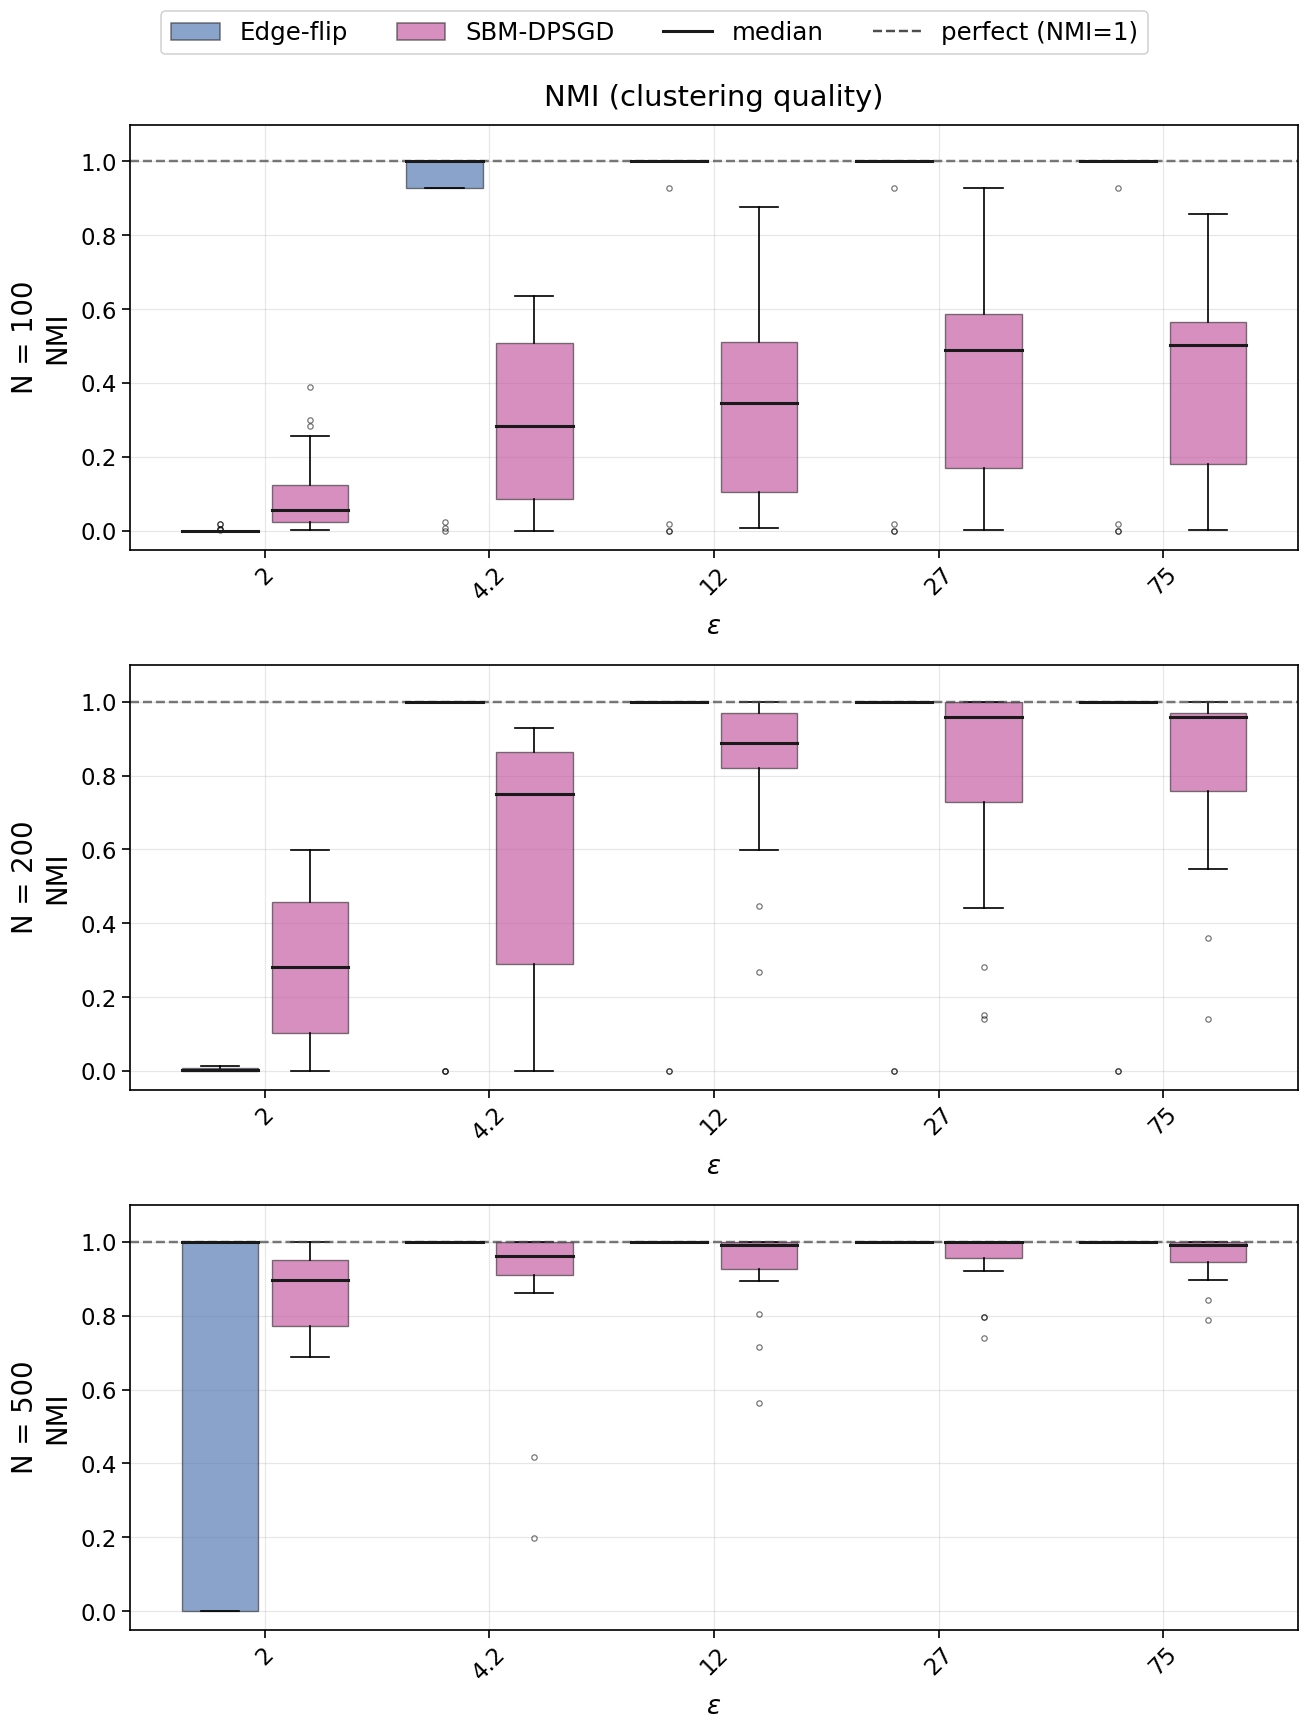

In [6]:
# ── Cell 8: Boxplots of NMI vs epsilon ──────────────────────────────────────
# Layout: one ROW per N, one large panel each -- same row-per-N structure as
# the beta and epochs figures, so the three read as a set. All rows share the
# [0, 1] NMI scale, so the N-to-N comparison down the column is direct.
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from plot_style import (apply_style, figsize, grouped_boxplot, method_color,
                        method_label, order_methods, reference_line,
                        BOX_ALPHA, MEDIAN_COLOR, REFERENCE_COLOR)

apply_style()

Ns = sorted(df["N"].unique())
methods = order_methods(df["method"].unique())

PANEL_W, PANEL_H = 9.0, 3.9

fig, axes = plt.subplots(
    len(Ns), 1,
    figsize=figsize(PANEL_W, PANEL_H * len(Ns)),
    squeeze=False,
)

for row, N in enumerate(Ns):
    ax = axes[row, 0]
    sub = df[df["N"] == N].dropna(subset=["nmi"])
    grouped_boxplot(ax, sub, "nmi", methods=methods)
    reference_line(ax, 1.0)
    ax.set_ylim(-0.05, 1.1)
    ax.set_xlabel(r"$\epsilon$")
    ax.set_ylabel(f"N = {N}\nNMI", fontsize=18)
    if row == 0:
        ax.set_title("NMI (clustering quality)", fontsize=19, pad=12)

handles = [Patch(facecolor=method_color(m), alpha=BOX_ALPHA, edgecolor="#333333",
                 label=method_label(m)) for m in methods]
handles += [
    Line2D([0], [0], color=MEDIAN_COLOR, linewidth=2.0, label="median"),
    Line2D([0], [0], color=REFERENCE_COLOR, linestyle="--", linewidth=1.6,
           label="perfect (NMI=1)"),
]
fig.legend(handles=handles, loc="upper center", ncol=len(handles),
           fontsize=16, frameon=True, bbox_to_anchor=(0.5, 1.005))

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

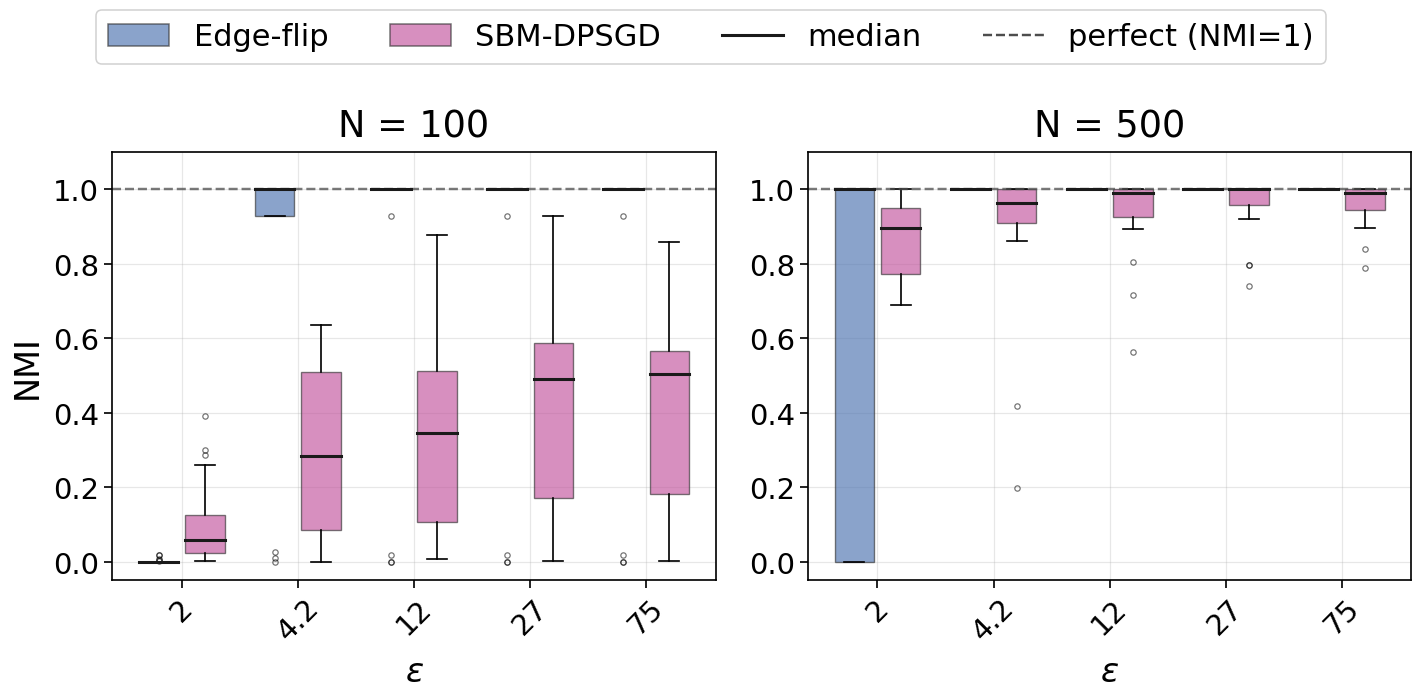

In [7]:
# ── Cell 8b: SLIDE version of the NMI figure (N = 200 dropped) ──────────────
# Same data as Cell 8, re-laid-out for a talk: N = 200 dropped, the two
# remaining N side by side (a 16:9 frame is wide, not tall), and type set in
# literal slide points. Both panels keep the [0, 1] NMI scale, so reading
# across the pair is direct.
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from plot_style import (apply_style, grouped_boxplot, method_color,
                        method_label, order_methods, reference_line,
                        BOX_ALPHA, MEDIAN_COLOR, REFERENCE_COLOR)

apply_style()

SLIDE_NS = [100, 500]
SLIDE_W, SLIDE_H = 13.33, 6.6   # 16:9 slide, minus space for a slide title
SLIDE_RC = {
    "font.size": 20,
    "axes.labelsize": 22,
    "xtick.labelsize": 19,
    "ytick.labelsize": 19,
    "legend.fontsize": 20,
}

dfs = df[df["N"].isin(SLIDE_NS)]
Ns_slide = [n for n in SLIDE_NS if n in set(dfs["N"])]
methods = order_methods(dfs["method"].unique())

with plt.rc_context(SLIDE_RC):
    fig, axes = plt.subplots(1, len(Ns_slide), figsize=(SLIDE_W, SLIDE_H),
                             squeeze=False)

    for col, N in enumerate(Ns_slide):
        ax = axes[0, col]
        sub = dfs[(dfs["N"] == N)].dropna(subset=["nmi"])
        grouped_boxplot(ax, sub, "nmi", methods=methods)
        reference_line(ax, 1.0)
        ax.set_ylim(-0.05, 1.1)
        ax.set_xlabel(r"$\epsilon$")
        ax.set_title(f"N = {N}", fontsize=24, pad=10)
        if col == 0:
            ax.set_ylabel("NMI", fontsize=22)

    handles = [Patch(facecolor=method_color(m), alpha=BOX_ALPHA,
                     edgecolor="#333333", label=method_label(m))
               for m in methods]
    handles += [
        Line2D([0], [0], color=MEDIAN_COLOR, linewidth=2.0, label="median"),
        Line2D([0], [0], color=REFERENCE_COLOR, linestyle="--", linewidth=1.6,
               label="perfect (NMI=1)"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=len(handles),
               fontsize=20, frameon=True, bbox_to_anchor=(0.5, 1.0))

    fig.tight_layout(rect=[0, 0, 1, 0.89])
    fig.savefig("figures/slide_nmi_unknown_labels.png", dpi=200)
    plt.show()